#  PopOut: MCTS e Árvores de Decisão

**Unidade Curricular:** Inteligência Artificial 2025/2026 (CC2006)  
**Projeto:** Adversarial Search Strategies and Decision Trees  
 

**Grupo 2, PL3:**
- Bruno Barros     (up202305457)
- Rui Pinto        (up202307701)
- Ruben Silva      (up202210316)

---

## Índice

1. [Introdução](#1-introdução)
2. [O Jogo PopOut](#2-o-jogo-popout)
3. [Implementação do Jogo](#3-implementação-do-jogo)
   - 3.1 Motor do Jogo (`popout_board.py`)
   - 3.2 Interface Visual (`display.py`)
   - 3.3 Interface Interativa (`interface.py`)
4. [Monte Carlo Tree Search](#4-monte-carlo-tree-search)
   - 4.1 Nó da Árvore (`MCTSNode`)
   - 4.2 Estratégias de Rollout
   - 4.3 Algoritmo Principal (`mcts_search`)
5. [Análise de Parâmetros do MCTS](#5-análise-de-parâmetros-do-mcts)
6. [Geração do Dataset PopOut](#6-geração-do-dataset-popout)
7. [Árvore de Decisão — Iris](#7-árvore-de-decisão--iris)
8. [Árvore de Decisão — PopOut](#8-árvore-de-decisão--popout)
9. [Modos de Jogo](#9-modos-de-jogo)
10. [Discussão de Resultados](#10-discussão-de-resultados)
11. [Conclusão e Referências](#11-conclusão-e-referências)

## 1. Introdução

Este projeto foi desenvolvido no âmbito da unidade curricular de Inteligência Artificial (CC2006) e tem como objetivo implementar e analisar duas técnicas clássicas de IA aplicadas ao jogo **PopOut**.

As duas técnicas implementadas são:

- **Monte Carlo Tree Search (MCTS)** com UCT — algoritmo de pesquisa adversarial que guia o computador a escolher a melhor jogada através de simulações aleatórias da árvore de jogo;
- **Árvores de Decisão ID3** — algoritmo de aprendizagem supervisionada implementado de raiz, treinado em dois datasets: o dataset Iris (exercício de warm-up) e um dataset gerado pelo próprio MCTS a partir de jogos de self-play.

### Organização do Notebook

O notebook está estruturado da seguinte forma:

| Secção | Conteúdo |
|--------|----------|
| 2 | Descrição do jogo PopOut e das suas regras especiais |
| 3 | Implementação do motor do jogo, interface visual e interface interativa |
| 4 | Implementação e explicação detalhada do algoritmo MCTS |
| 5 | Análise experimental dos hiperparâmetros do MCTS |
| 6 | Geração do dataset PopOut através de self-play MCTS |
| 7 | Árvore de Decisão ID3 aplicada ao dataset Iris |
| 8 | Árvore de Decisão ID3 aplicada ao dataset PopOut |
| 9 | Demonstração dos modos de jogo |
| 10 | Discussão crítica dos resultados |
| 11 | Conclusão e referências |

### Restrições de Implementação

- A árvore de decisão ID3 foi implementada **de raiz**, sem recurso ao scikit-learn ou bibliotecas equivalentes para treino ou predição;
- O scikit-learn é utilizado **apenas** para carregar o dataset Iris;
- Todas as métricas de avaliação (acurácia, matriz de confusão, precision, recall, F1) foram implementadas de raiz em `evaluation.py`.

## 2. O Jogo PopOut

O **PopOut** é uma variante do Connect-4 em que dois jogadores alternam turnos num tabuleiro de **6 linhas × 7 colunas**, com o objetivo de ser o primeiro a alinhar **4 peças consecutivas** na horizontal, vertical ou diagonal.

A grande novidade do PopOut é a introdução de um segundo tipo de movimento — o **pop**. Em vez de apenas colocar peças pelo topo (*drop*), um jogador pode também **remover uma das suas próprias peças da linha de baixo** (*pop*). Quando isso acontece, todas as peças acima dessa coluna descem uma casa, alterando completamente a configuração do tabuleiro e abrindo novas possibilidades táticas.

### 2.1 Tipos de Movimento

| Movimento | Descrição | Condição |
|-----------|-----------|----------|
| **Drop** | Coloca uma peça no topo de uma coluna | A coluna não pode estar cheia |
| **Pop** | Remove a própria peça da base de uma coluna | O jogador deve ter uma peça na linha de baixo dessa coluna |
| **Draw** | Declara empate | Apenas quando o tabuleiro está completamente cheio |

### 2.2 Regras Especiais

| # | Regra | Descrição |
|---|-------|-----------|
| 1 | **Vitória simultânea** | Se um *pop* cria 4 em linha para **ambos** os jogadores, o jogador que fez o *pop* **ganha** |
| 2 | **Empate por tabuleiro cheio** | Quando o tabuleiro está cheio, o jogador pode fazer *pop* ou declarar **empate** |
| 3 | **Empate por repetição** | Se o mesmo estado se repetir **6 vezes consecutivas**, o árbitro declara **empate** automaticamente |

### 2.3 Codificação dos Movimentos

Na nossa implementação, cada movimento é representado por um tuplo Python:

```python
('drop', col)  # colocar peça na coluna col (0–6)
('pop',  col)  # remover peça da base da coluna col (0–6)
('draw', None) # declarar empate
```

### 2.4 Porquê é o PopOut um Desafio para a IA?

O Connect-4 tem aproximadamente **4,5 mil milhões** de estados possíveis. O PopOut aumenta este número significativamente porque:

- O mesmo estado pode ser atingido por múltiplos caminhos diferentes
- Os movimentos pop podem desfazer jogadas anteriores, criando ciclos
- O fator de ramificação é maior — em média, um jogador tem mais opções por turno

Isto torna o PopOut um problema ideal para testar algoritmos como o MCTS, que lidam bem com espaços de estados muito grandes sem necessitar de uma função de avaliação manual.

## 3. Implementação do Jogo

A implementação do jogo PopOut está organizada em três ficheiros principais, cada um com uma responsabilidade bem definida:

- **`src/game/popout_board.py`** — Motor do jogo: contém toda a lógica de regras, movimentos e deteção de vitória. É o núcleo da implementação e é utilizado por todos os outros módulos.
- **`src/game/display.py`** — Interface visual: responsável por renderizar o tabuleiro em HTML dentro do Jupyter Notebook, com animações e indicação de turno.
- **`src/game/interface.py`** — Interface interativa: implementa o loop de jogo com ipywidgets, permitindo que humanos joguem através de botões e que o computador pense em segundo plano.

Esta separação de responsabilidades permite que o motor do jogo seja reutilizado de forma independente — tanto pelo MCTS durante a pesquisa, como pela interface visual durante o jogo interativo.

### 3.1 Motor do Jogo (`popout_board.py`)

O ficheiro `src/game/popout_board.py` é o núcleo de toda a implementação. Define a classe **`PopOutBoard`**, que representa o estado completo de uma partida de PopOut em qualquer momento do jogo. É utilizado por todos os outros módulos do projeto — desde a interface visual até ao algoritmo MCTS, que cria milhares de cópias do tabuleiro durante a pesquisa.

O tabuleiro é representado internamente por uma matriz **NumPy 6×7**, onde cada célula pode tomar um de três valores:

| Valor | Significado |
|-------|-------------|
| `0` | Célula vazia |
| `1` | Peça do Jogador 1 (vermelho) |
| `2` | Peça do Jogador 2 (amarelo) |

Para além do tabuleiro, a classe mantém o estado completo do jogo:
- O jogador atual (`current_player`)
- Se o jogo terminou (`is_game_over`)
- O vencedor, se houver (`winner`)
- O histórico de estados já vistos, para detetar repetições (Regra 3)

#### Importações necessárias

In [17]:
import numpy as np

#### Classe `PopOutBoard`

A classe `PopOutBoard` é inicializada com um tabuleiro vazio e o Jogador 1 a começar. Define também três constantes de classe que representam os possíveis valores de cada célula do tabuleiro.

In [18]:
class PopOutBoard:
    """Mutable game state for a PopOut match."""

    ROWS: int = 6  # número de linhas do tabuleiro
    COLS: int = 7  # número de colunas do tabuleiro

    # valores possíveis para cada célula do tabuleiro
    EMPTY:    int = 0  # célula vazia
    PLAYER_1: int = 1  # peça do jogador 1 (vermelho)
    PLAYER_2: int = 2  # peça do jogador 2 (amarelo)

    def __init__(self) -> None:
        """Inicializa um novo tabuleiro vazio com o Jogador 1 a começar."""
        self.board = np.zeros((self.ROWS, self.COLS), dtype=np.int8)  # tabuleiro vazio 6×7
        self.current_player: int = self.PLAYER_1  # jogador 1 começa sempre
        self.is_game_over: bool = False           # jogo em curso
        self.winner: int | None = None            # sem vencedor ainda
        self._seen_states: set[bytes] = set()     # histórico de estados (para regra 3)
        self._consecutive_repeats: int = 0        # contador de repetições consecutivas
        self._record_state()                      # regista o estado inicial no histórico

Os atributos principais da classe são:

| Atributo | Tipo | Descrição |
|----------|------|-----------|
| `board` | `np.ndarray` (6×7) | Matriz que representa o tabuleiro |
| `current_player` | `int` | Jogador atual (1 ou 2) |
| `is_game_over` | `bool` | Indica se o jogo terminou |
| `winner` | `int` ou `None` | Vencedor (1 ou 2), 0 se empate, None se em curso |
| `_seen_states` | `set` | Conjunto de estados já vistos (para detetar repetições) |
| `_consecutive_repeats` | `int` | Contador de estados repetidos consecutivos |

#### Função `copy()`

A função `copy()` retorna uma cópia profunda do estado atual do tabuleiro. É fundamental para o algoritmo MCTS, que precisa de criar milhares de cópias do estado do jogo durante a pesquisa sem alterar o estado original.

In [19]:
def copy(self) -> "PopOutBoard":
    """Return a deep copy of the board (needed by search algorithms)."""
    clone = PopOutBoard.__new__(PopOutBoard)  # cria nova instância sem chamar __init__
    clone.board = self.board.copy()           # copia a matriz do tabuleiro
    clone.current_player = self.current_player  # copia o jogador atual
    clone.is_game_over = self.is_game_over    # copia o estado do jogo
    clone.winner = self.winner                # copia o vencedor
    clone._seen_states = self._seen_states.copy()  # copia o histórico de estados
    clone._consecutive_repeats = self._consecutive_repeats  # copia o contador de repetições
    return clone  # retorna a cópia

Note-se que em vez de usar `deepcopy()` do Python (que é lento), foi feita uma cópia manual atributo a atributo. Isto é uma otimização importante pois o MCTS chama esta função milhares de vezes por segundo durante a pesquisa.

#### Função `get_legal_moves()`

A função `get_legal_moves()` retorna a lista de todos os movimentos legais disponíveis para o jogador atual. É chamada tanto pela interface de jogo (para mostrar as opções ao jogador humano) como pelo MCTS (para expandir os nós da árvore de pesquisa).

Um movimento é legal se:
- **Drop**: a coluna ainda não está cheia (a célula do topo está vazia)
- **Pop**: o jogador atual tem uma peça na linha de baixo dessa coluna
- **Draw**: apenas disponível quando o tabuleiro está completamente cheio

In [20]:
def get_legal_moves(self) -> list[tuple]:
    """Return all legal moves for the current player."""
    if self.is_game_over:  # se o jogo terminou, não há movimentos legais
        return []

    moves: list[tuple] = []  # lista de movimentos legais
    board_full = True         # assume tabuleiro cheio até encontrar célula vazia

    for col in range(self.COLS):  # percorre todas as colunas
        if self.board[0, col] == self.EMPTY:  # se o topo da coluna está vazio
            moves.append(('drop', col))        # drop é legal nesta coluna
            board_full = False                 # tabuleiro não está cheio
        if self.board[self.ROWS - 1, col] == self.current_player:  # se o jogador tem peça na base
            moves.append(('pop', col))         # pop é legal nesta coluna

    if board_full:                    # se o tabuleiro estiver completamente cheio
        moves.append(('draw', None))  # o jogador pode declarar empate

    return moves  # retorna a lista de movimentos legais

#### Função `apply_move()`

A função `apply_move()` é o dispatcher principal que aplica um movimento ao tabuleiro. Recebe um tuplo `(tipo, coluna)` e chama a função correspondente (`_drop`, `_pop` ou marca empate). Após aplicar o movimento, troca de jogador, verifica vitória e regista o novo estado para deteção de repetições.

In [22]:
def apply_move(self, move: tuple) -> None:
    """Apply a move to the board and update game state."""
    move_type, col = move  # extrai tipo e coluna do movimento
    
    if move_type == 'drop':       # se for drop
        self._drop(col)           # coloca peça na coluna
    elif move_type == 'pop':      # se for pop
        self._pop(col)            # remove peça da base da coluna
    elif move_type == 'draw':     # se for declaração de empate
        self.is_game_over = True  # termina o jogo
        self.winner = 0           # empate (não há vencedor)
        return                    # não precisa de continuar
    
    self._check_winner()          # verifica se alguém ganhou com este movimento
    if not self.is_game_over:     # se o jogo ainda não terminou
        self._switch_player()     # troca de jogador
        self._record_state()      # regista o novo estado no histórico

Note-se que a declaração de empate (`draw`) termina imediatamente o jogo sem trocar de jogador. Já os movimentos `drop` e `pop` sempre fazem a troca de jogador após serem aplicados, a não ser que criem uma vitória.



#### Funções `_drop()` e `_pop()`

Estas duas funções privadas implementam a lógica dos dois tipos principais de movimento no PopOut.

**`_drop(col)`** — coloca uma peça do jogador atual na coluna especificada. A peça "cai" até à primeira linha livre (de baixo para cima).

**`_pop(col)`** — remove a peça da linha de baixo da coluna especificada e aplica gravidade: todas as peças acima descem uma casa.

In [43]:
def _drop(self, col: int) -> None:
    """Drop a piece into the given column."""
    for row in range(self.ROWS - 1, -1, -1):  # percorre de baixo para cima
        if self.board[row, col] == self.EMPTY:  # encontrou a primeira linha vazia
            self.board[row, col] = self.current_player  # coloca a peça do jogador atual
            return  # termina a função

def _pop(self, col: int) -> None:
    """Remove bottom piece from column and apply gravity."""
    for row in range(self.ROWS - 1, 0, -1):  # percorre de baixo para cima (exceto topo)
        self.board[row, col] = self.board[row - 1, col]  # copia a peça de cima para baixo
    self.board[0, col] = self.EMPTY  # liberta a célula do topo

A função `_drop()` para assim que encontra a primeira célula vazia (de baixo para cima), simulando a queda da peça por gravidade.

A função `_pop()` percorre a coluna de baixo para cima, copiando cada peça para a posição abaixo. No final, a célula do topo fica vazia. Isto simula a gravidade após a remoção da peça da base.

#### Funções `_check_winner()` e `_has_four()`

Estas funções são responsáveis por detetar se o jogo terminou com vitória ou empate.

**`_check_winner()`** — verifica se o último movimento criou uma vitória. Também aplica a Regra 1 (vitória simultânea) e a Regra 3 (empate por repetição).

**`_has_four(row, col, player)`** — verifica se existe uma linha de 4 peças consecutivas do jogador especificado, começando pela posição (row, col). Verifica as 4 direções: horizontal, vertical e ambas as diagonais.

In [44]:
def _check_winner(self) -> None:
    """Check if the game is over after the last move."""
    # Regra 3: empate por repetição (6 vezes consecutivas)
    if self._consecutive_repeats >= 6:  # se o estado se repetiu 6 vezes
        self.is_game_over = True        # termina o jogo
        self.winner = 0                 # empate
        return
    
    # Procura vitória no tabuleiro inteiro
    for row in range(self.ROWS):               # percorre todas as linhas
        for col in range(self.COLS):           # percorre todas as colunas
            if self.board[row, col] == self.EMPTY:  # célula vazia, salta
                continue
            player = self.board[row, col]      # jogador nesta célula
            if self._has_four(row, col, player):  # verifica se este jogador tem 4 em linha
                self.is_game_over = True       # termina o jogo
                self.winner = player           # este jogador ganhou
                return

def _has_four(self, row: int, col: int, player: int) -> bool:
    """Check if there are 4 consecutive pieces starting from (row, col)."""
    directions = [
        (0, 1),   # horizontal →
        (1, 0),   # vertical ↓
        (1, 1),   # diagonal principal ↘
        (1, -1)   # diagonal secundária ↙
    ]
    
    for dr, dc in directions:  # para cada direção
        count = 0              # contador de peças consecutivas
        for i in range(4):     # verifica 4 posições nesta direção
            r = row + i * dr   # nova linha
            c = col + i * dc   # nova coluna
            if 0 <= r < self.ROWS and 0 <= c < self.COLS:  # dentro do tabuleiro
                if self.board[r, c] == player:  # peça do jogador nesta posição
                    count += 1  # incrementa contador
                else:
                    break       # sequência interrompida
            else:
                break           # fora do tabuleiro
        if count == 4:          # encontrou 4 consecutivas
            return True         # vitória
    
    return False  # não encontrou 4 em linha

#### Funções `_switch_player()` e `_record_state()`

Estas duas funções auxiliares gerem a alternância de turnos e o histórico de estados.

**`_switch_player()`** — alterna o jogador atual (1 ↔ 2).

**`_record_state()`** — regista o estado atual do tabuleiro no histórico para detetar repetições (Regra 3). Se o estado for igual ao anterior, incrementa o contador de repetições consecutivas; caso contrário, reinicia o contador.

In [45]:
def _switch_player(self) -> None:
    """Switch to the other player."""
    if self.current_player == self.PLAYER_1:  # se o jogador atual é o 1
        self.current_player = self.PLAYER_2   # passa para o jogador 2
    else:                                     # caso contrário
        self.current_player = self.PLAYER_1   # passa para o jogador 1

def _record_state(self) -> None:
    """Record current board state to detect repetitions (Rule 3)."""
    state_hash = self.board.tobytes()  # converte o tabuleiro em bytes (hash do estado)
    
    if state_hash in self._seen_states:       # se este estado já foi visto antes
        self._consecutive_repeats += 1        # incrementa contador de repetições
    else:                                     # se é um estado novo
        self._consecutive_repeats = 0         # reinicia o contador
        self._seen_states.add(state_hash)     # adiciona ao histórico

### 3.2 Interface Visual (`display.py`)

O ficheiro `src/game/display.py` é responsável por renderizar o tabuleiro em HTML dentro do Jupyter Notebook. Gera código HTML/CSS com animações e estilos visuais que tornam o jogo mais intuitivo e agradável de acompanhar.

A função principal é `display_board()`, que recebe um objeto `PopOutBoard` e retorna HTML pronto a ser renderizado pelo Jupyter através do `IPython.display.HTML()`.

#### Características visuais implementadas:

- Peças com gradientes radiais (vermelho e amarelo)
- Animação de queda quando uma peça é colocada (*drop*)
- Destaque da última jogada com animação pulsante
- Tabuleiro com efeito 3D e sombras
- Labels de coluna (0–6) para facilitar a escolha de movimentos
- Indicador de turno ("Vez do Jogador 1 / 2")

A implementação completa está no ficheiro, mas aqui está a assinatura da função principal:

In [23]:
from IPython.display import HTML
import random

def display_board(board: PopOutBoard, show_last_move: bool = True) -> HTML:
    """
    Renderiza o tabuleiro PopOut em HTML com animações e estilos.
    
    Args:
        board: objeto PopOutBoard a renderizar
        show_last_move: se True, destaca a última jogada com animação
    
    Returns:
        objeto IPython.display.HTML pronto para renderização
    """
    # gera um ID único para este tabuleiro (evita conflitos de CSS)
    uid = ''.join(random.choices('abcdefghijklmnopqrstuvwxyz0123456789', k=10))
    
    # constrói o HTML completo (código omitido por brevidade — ver display.py)
    html = f"<style>...</style><div id='po{uid}'>...</div>"
    
    return HTML(html)

### 3.3 Interface Interativa (`interface.py`)

O ficheiro `src/game/interface.py` implementa a interface de jogo completa usando **ipywidgets**, permitindo que humanos joguem contra o computador (MCTS ou Árvore de Decisão) através de botões interativos.

A função principal é `play_game()`, que cria uma interface gráfica com:
- Botões para cada coluna (0–6) para fazer *drop*
- Botões para cada coluna onde o jogador pode fazer *pop*
- Botão de declarar empate (quando o tabuleiro está cheio)
- Área de output que mostra o tabuleiro em tempo real
- Mensagens de turno e resultado final

#### Função `play_game()`

Esta função aceita dois agentes como argumentos: um para cada jogador. Um agente pode ser:
- `'human'` — o jogador humano clica nos botões
- `make_mcts_agent(...)` — o computador joga com MCTS
- `make_dt_agent(...)` — o computador joga com a Árvore de Decisão

In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def play_game(player1_agent, player2_agent):
    """
    Cria uma interface interativa para jogar PopOut.
    
    Args:
        player1_agent: agente para o jogador 1 ('human' ou função)
        player2_agent: agente para o jogador 2 ('human' ou função)
    
    A interface atualiza automaticamente quando:
    - O jogador humano clica num botão
    - O computador termina de pensar (usa threading para não bloquear)
    """
    board = PopOutBoard()  # inicializa tabuleiro vazio
    output = widgets.Output()  # área de output para o tabuleiro
    
    # cria botões para cada coluna (drop e pop)
    drop_buttons = [widgets.Button(description=f'Drop {i}') for i in range(7)]
    pop_buttons = [widgets.Button(description=f'Pop {i}') for i in range(7)]
    draw_button = widgets.Button(description='Declarar Empate', button_style='warning')
    
    # define o comportamento quando cada botão é clicado
    def on_drop_click(col):
        # aplica o movimento, atualiza o display, verifica vitória
        # se o próximo jogador for o computador, chama o agente em threading
        pass  # (código completo em interface.py)
    
    # liga os botões às funções (event handlers)
    for i, btn in enumerate(drop_buttons):
        btn.on_click(lambda b, col=i: on_drop_click(col))
    
    # monta o layout e exibe
    display(widgets.VBox([widgets.HBox(drop_buttons), widgets.HBox(pop_buttons), draw_button, output]))
    
    # renderiza o tabuleiro inicial
    with output:
        display(display_board(board))

O código completo está em `src/game/interface.py` e implementa toda a lógica de gestão de turnos, atualização de botões (enable/disable), threading para o computador pensar em segundo plano, e deteção de fim de jogo. Foi omitido aqui por brevidade, mas a estrutura acima resume o funcionamento geral.

### 3.4 Demonstração

Para verificar que o motor do jogo está a funcionar corretamente, vamos criar um estado intermédio de jogo e visualizá-lo com a interface HTML.

Primeiro, fazemos o setup inicial e importamos os módulos necessários:

In [25]:
import sys
import os
import math
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Instalar dependências (se necessário)
os.system('pip install -r requirements.txt -q')

# Imports do projeto
from src.game.popout_board import PopOutBoard
from src.game.display import display_board
from src.game.interface import play_game
from src.ai.agents import random_agent, make_mcts_agent, make_dt_agent

# Diretórios
DATA_DIR = 'data'
FIGURES_DIR = os.path.join('outputs', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup completo!')

Setup completo!


Agora vamos criar um tabuleiro com alguns movimentos já aplicados para demonstrar a renderização HTML:

In [26]:
# Cria um tabuleiro vazio
demo = PopOutBoard()

# Aplica uma sequência de movimentos para criar um estado intermédio
moves = [
    ('drop', 3),  # Jogador 1 (vermelho) coloca no centro
    ('drop', 3),  # Jogador 2 (amarelo) coloca no centro
    ('drop', 2),  # Jogador 1
    ('drop', 4),  # Jogador 2
    ('drop', 2),  # Jogador 1
    ('drop', 4),  # Jogador 2
    ('drop', 3),  # Jogador 1
    ('drop', 2),  # Jogador 2
]

for move in moves:
    demo.apply_move(move)

# Renderiza o tabuleiro
display_board(demo)

O tabuleiro renderizado acima mostra um estado intermédio do jogo com 8 movimentos aplicados. As peças vermelhas pertencem ao Jogador 1 e as amarelas ao Jogador 2.

Podemos também verificar os movimentos legais disponíveis neste estado:O tabuleiro renderizado acima mostra um estado intermédio do jogo com 8 movimentos aplicados. A última jogada está destacada com uma animação pulsante. As peças vermelhas pertencem ao Jogador 1 e as amarelas ao Jogador 2.



In [27]:
print(f"Jogador atual: {demo.current_player}")
print(f"Movimentos legais: {demo.get_legal_moves()}")
print(f"Jogo terminado: {demo.is_game_over}")

Jogador atual: 1
Movimentos legais: [('drop', 0), ('drop', 1), ('drop', 2), ('pop', 2), ('drop', 3), ('pop', 3), ('drop', 4), ('drop', 5), ('drop', 6)]
Jogo terminado: False


## 4. Monte Carlo Tree Search

O **Monte Carlo Tree Search (MCTS)** é um algoritmo de pesquisa adversarial que constrói incrementalmente uma árvore de estatísticas — a *stats tree* — guiando a IA a explorar apenas os ramos mais promissores da árvore de jogo. Ao contrário de algoritmos como o Minimax (que exploram toda a árvore até uma certa profundidade), o MCTS concentra o esforço computacional nas jogadas que parecem mais vantajosas com base em simulações.

A nossa implementação está organizada em três ficheiros:

- **`src/ai/mcts.py`** — Implementação do algoritmo MCTS: nós da árvore, fórmula UCT, rollouts e pesquisa
- **`src/ai/agents.py`** — Factories para criar agentes (random, MCTS, decision tree)
- **`src/utils/evaluation.py`** — Funções para torneios e avaliação de desempenho

### 4.1 As Quatro Fases do MCTS

O algoritmo repete ciclicamente quatro fases até esgotar o tempo ou número de iterações disponível:

| Fase | Descrição |
|------|-----------|
| **Selection** | A partir da raiz, desce na árvore escolhendo sempre o filho com maior valor UCT, até encontrar um nó com jogadas ainda por explorar |
| **Expansion** | Adiciona um ou mais novos nós à árvore, correspondendo a jogadas ainda não tentadas |
| **Simulation** | A partir do novo nó, joga até ao fim do jogo (*rollout*) usando uma estratégia (random, greedy ou heuristic); obtém-se um resultado (vitória, derrota ou empate) |
| **Backpropagation** | O resultado é propagado de volta até à raiz, atualizando o contador de visitas $N$ e a recompensa acumulada $Q$ de cada nó ancestral |

### 4.2 Fórmula UCT — Upper Confidence Bound for Trees

Durante a fase de **Selection**, o MCTS escolhe qual filho visitar usando a fórmula **UCT**:

$$\text{UCT}(v) = \underbrace{\frac{Q(v)}{N(v)}}_{\text{exploitation}} + C \cdot \underbrace{\sqrt{\frac{\ln N(\text{parent})}{N(v)}}}_{\text{exploration}}$$

onde:
- $Q(v)$ — recompensa total acumulada no nó $v$ (soma de vitórias)
- $N(v)$ — número de vezes que o nó $v$ foi visitado
- $N(\text{parent})$ — número de vezes que o nó pai foi visitado
- $C$ — **constante de exploração** (valor teórico ótimo: $\sqrt{2}$)

#### O Papel Crítico da Constante $C$

A constante $C$ controla o equilíbrio entre dois comportamentos opostos:

| Valor de $C$ | Comportamento |
|------------|---------------|
| **$C$ elevado** | O algoritmo tende a **explorar** nós pouco visitados, mesmo que tenham baixa taxa de vitória |
| **$C$ baixo** | O algoritmo tende a **exploitar** os nós mais vitoriosos, ignorando alternativas menos conhecidas |
| **$C = \sqrt{2}$** | Equilíbrio teórico ótimo entre exploração e exploitação (demonstrado matematicamente) |

> **Exemplo:** Um nó com 65/100 vitórias é preferível a um com 2/3 vitórias, porque o segundo tem muita incerteza associada. A fórmula UCT garante que, à medida que o número de simulações aumenta, o nó mais visitado tende a ser também o com maior taxa de vitória.

### 4.3 Extensões Implementadas

Para além do comportamento standard do MCTS, implementámos várias extensões que permitem controlar o trade-off entre qualidade de decisão e tempo de computação.

#### Node Selection

| Extensão | Descrição |
|----------|-----------|
| **Early stopping** | Para as iterações quando o melhor filho atinge uma taxa de vitória dominante (configurável via threshold). Poupa tempo de computação sem sacrificar qualidade da decisão — útil em jogadas onde a melhor opção é óbvia |
| **Max time** | Limite de tempo por jogada (em segundos) como alternativa ao número fixo de iterações. Permite decisões mais rápidas em posições simples |
| **Expand k** | Em vez de expandir 1 filho por iteração (standard MCTS), expande $k$ filhos de uma só vez. Valores de $k$ maiores aumentam a largura da árvore mais rapidamente mas reduzem a profundidade de pesquisa |

#### Rollout Strategies

A fase de simulação pode usar diferentes estratégias para jogar até ao fim do jogo. Implementámos três:

| Estratégia | Descrição |
|-----------|-----------|
| **random** | Joga movimentos completamente aleatórios até ao fim. É a estratégia mais rápida por simulação mas produz o sinal de menor qualidade — qualquer jogada, boa ou má, tem igual probabilidade |
| **greedy** | Aplica uma heurística de **1 nível** em cada passo: (1) se existir jogada que ganha imediatamente → joga-a, (2) se o adversário tiver jogada vencedora → bloqueia-a, (3) caso contrário → escolhe a jogada com maior pontuação posicional (preferência por colunas centrais). Mais rápida que `heuristic` e já introduz conhecimento do domínio |
| **heuristic** | Aplica uma heurística de **2 níveis**: (1) vitória imediata, (2) bloqueio de vitória adversária 1-nível, (3) entre as restantes, elimina jogadas que dariam ao adversário uma vitória imediata na resposta (verificação 2-níveis), (4) jogada aleatória entre as seguras. É a mais lenta por simulação mas produz o sinal de maior qualidade |

Estas extensões serão analisadas experimentalmente na **Secção 5**.

### 4.4 Seleção Final da Jogada

Após terminar todas as iterações, o MCTS escolhe a jogada final usando **robust selection**: seleciona o filho da raiz com maior número de visitas $N$, e não o maior $Q/N$. Esta abordagem é mais fiável porque um nó com muitas visitas tem estatísticas mais estáveis do que um nó com poucas visitas e um resultado temporariamente favorável.

### 4.5 Implementação do MCTS (`mcts.py`)

O ficheiro `src/ai/mcts.py` contém toda a lógica do algoritmo MCTS. Está organizado em duas classes principais:

- **`MCTSNode`** — Representa um nó da árvore de pesquisa (stats tree)
- **`mcts_search()`** — Função principal que executa o algoritmo completo

Além disso, contém três funções de rollout (`rollout_random`, `rollout_greedy`, `rollout_heuristic`) que implementam as estratégias de simulação descritas anteriormente.

#### Importações necessárias

In [28]:
import math
import random
import time
from typing import Callable
from src.game.popout_board import PopOutBoard

#### Classe `MCTSNode`

Um nó da árvore MCTS armazena as estatísticas de um estado do jogo. Cada nó mantém:
- O número de visitas $N$
- A recompensa acumulada $Q$ (soma de resultados)
- Os filhos já expandidos (mapeamento de movimento → nó)
- As jogadas ainda não tentadas

In [29]:
class MCTSNode:
    """Node in the MCTS search tree."""
    
    def __init__(self, state: PopOutBoard, parent=None, move=None):
        """
        Inicializa um nó da árvore MCTS.
        
        Args:
            state: estado do jogo neste nó
            parent: nó pai (None se for a raiz)
            move: movimento que levou a este nó
        """
        self.state = state                      # estado do jogo
        self.parent = parent                    # nó pai
        self.move = move                        # movimento que criou este nó
        self.children: dict = {}                # filhos expandidos (move → MCTSNode)
        self.N: int = 0                         # número de visitas
        self.Q: float = 0.0                     # recompensa acumulada
        self.untried_moves = state.get_legal_moves()  # movimentos ainda não expandidos

#### Função `uct_value()`

Calcula o valor UCT de um nó para a fase de seleção. Se o nó nunca foi visitado ($N = 0$), retorna infinito para forçar a exploração.

In [30]:
def uct_value(self, c: float = math.sqrt(2)) -> float:
    """
    Calcula o valor UCT (Upper Confidence Bound for Trees).
    
    Args:
        c: constante de exploração (padrão: √2)
    
    Returns:
        valor UCT para este nó
    """
    if self.N == 0:  # se nunca foi visitado
        return float('inf')  # força exploração (valor infinito)
    
    # Q/N: taxa de vitória (exploitation)
    exploitation = self.Q / self.N
    
    # √(ln(N_parent) / N): termo de exploração
    exploration = c * math.sqrt(math.log(self.parent.N) / self.N)
    
    return exploitation + exploration  # UCT = exploitation + exploration

#### Função `select_child()`

Seleciona o filho com maior valor UCT. É chamada recursivamente durante a fase de **Selection**.

In [31]:
def select_child(self, c: float = math.sqrt(2)):
    """
    Seleciona o filho com maior valor UCT.
    
    Args:
        c: constante de exploração
    
    Returns:
        filho com maior UCT
    """
    return max(self.children.values(), key=lambda node: node.uct_value(c))

#### Função `expand()`

Adiciona um novo filho à árvore, escolhendo um movimento ainda não explorado. Remove o movimento da lista de `untried_moves` e adiciona o novo nó aos `children`. Retorna o nó recém-criado.

In [32]:
def expand(self, expand_k: int = 1) -> 'MCTSNode':
    """
    Expande k novos filhos (fase de Expansion).
    
    Args:
        expand_k: número de filhos a expandir (padrão: 1)
    
    Returns:
        último nó expandido
    """
    new_node = None
    for _ in range(min(expand_k, len(self.untried_moves))):  # expande até k filhos
        move = self.untried_moves.pop()       # remove movimento da lista
        next_state = self.state.copy()        # copia o estado atual
        next_state.apply_move(move)           # aplica o movimento
        child = MCTSNode(next_state, parent=self, move=move)  # cria novo nó
        self.children[move] = child           # adiciona aos filhos
        new_node = child                      # guarda referência
    return new_node  # retorna o último nó expandido

#### Funções de Rollout

As funções de rollout implementam diferentes estratégias para simular o jogo até ao fim (fase de **Simulation**). Todas recebem um estado do jogo e retornam o vencedor (1, 2 ou 0 para empate).

##### `rollout_random()`

Estratégia mais simples: joga movimentos completamente aleatórios até o jogo terminar.

In [33]:
def rollout_random(state: PopOutBoard) -> int:
    """
    Simula um jogo com movimentos aleatórios até ao fim.
    
    Args:
        state: estado inicial para a simulação
    
    Returns:
        vencedor (1, 2 ou 0 para empate)
    """
    state = state.copy()  # copia o estado (não modifica o original)
    
    while not state.is_game_over:  # enquanto o jogo não terminar
        moves = state.get_legal_moves()  # obtém movimentos legais
        move = random.choice(moves)      # escolhe um aleatoriamente
        state.apply_move(move)           # aplica o movimento
    
    return state.winner  # retorna o vencedor

##### `rollout_greedy()`

Estratégia de 1 nível: verifica se existe vitória imediata ou bloqueio necessário. Caso contrário, prefere jogadas em colunas centrais.

In [34]:
def rollout_greedy(state: PopOutBoard) -> int:
    """
    Simula um jogo com heurística de 1 nível:
    1. Vitória imediata → joga
    2. Bloqueio de vitória adversária → joga
    3. Caso contrário → prefere colunas centrais
    
    Args:
        state: estado inicial para a simulação
    
    Returns:
        vencedor (1, 2 ou 0 para empate)
    """
    state = state.copy()  # copia o estado
    
    while not state.is_game_over:  # enquanto o jogo não terminar
        moves = state.get_legal_moves()  # movimentos legais
        player = state.current_player    # jogador atual
        opponent = 3 - player            # adversário (1→2, 2→1)
        
        # 1. Verifica vitória imediata
        for move in moves:
            test_state = state.copy()
            test_state.apply_move(move)
            if test_state.winner == player:  # se ganhar com este movimento
                state.apply_move(move)       # joga-o
                break
        else:
            # 2. Verifica bloqueio de vitória adversária
            for move in moves:
                test_state = state.copy()
                test_state.apply_move(move)
                # verifica se o adversário tem vitória na próxima jogada
                opponent_moves = test_state.get_legal_moves()
                for opp_move in opponent_moves:
                    test2 = test_state.copy()
                    test2.apply_move(opp_move)
                    if test2.winner == opponent:  # adversário ganharia
                        state.apply_move(move)    # bloqueia
                        break
                else:
                    continue
                break
            else:
                # 3. Caso contrário: prefere colunas centrais
                # atribui pontuação: coluna 3 (centro) = melhor
                def score(m):
                    if m[0] == 'drop':
                        return -abs(m[1] - 3)  # quanto mais perto do centro, melhor
                    return -10  # pop tem prioridade baixa
                
                move = max(moves, key=score)  # escolhe movimento com melhor pontuação
                state.apply_move(move)
    
    return state.winner  # retorna o vencedor

##### `rollout_heuristic()`

Estratégia de 2 níveis: para além de vitória imediata e bloqueio, elimina jogadas que dariam ao adversário uma vitória imediata na resposta (verificação 2-níveis). É a estratégia mais lenta mas produz o sinal de maior qualidade.

In [35]:
def rollout_heuristic(state: PopOutBoard) -> int:
    """
    Simula um jogo com heurística de 2 níveis:
    1. Vitória imediata → joga
    2. Bloqueio de vitória adversária 1-nível → joga
    3. Elimina jogadas que dão vitória ao adversário 2-níveis
    4. Joga aleatoriamente entre as restantes
    
    Args:
        state: estado inicial para a simulação
    
    Returns:
        vencedor (1, 2 ou 0 para empate)
    """
    state = state.copy()  # copia o estado
    
    while not state.is_game_over:  # enquanto o jogo não terminar
        moves = state.get_legal_moves()  # movimentos legais
        player = state.current_player    # jogador atual
        opponent = 3 - player            # adversário
        
        # 1. Vitória imediata
        for move in moves:
            test_state = state.copy()
            test_state.apply_move(move)
            if test_state.winner == player:  # ganha imediatamente
                state.apply_move(move)
                break
        else:
            # 2. Bloqueio de vitória adversária 1-nível
            blocking_move = None
            for move in moves:
                test_state = state.copy()
                test_state.apply_move(move)
                opp_moves = test_state.get_legal_moves()
                for opp_move in opp_moves:
                    test2 = test_state.copy()
                    test2.apply_move(opp_move)
                    if test2.winner == opponent:  # adversário ganharia
                        blocking_move = move
                        break
                if blocking_move:
                    break
            
            if blocking_move:
                state.apply_move(blocking_move)  # bloqueia
            else:
                # 3. Filtra jogadas que dão vitória ao adversário 2-níveis
                safe_moves = []
                for move in moves:
                    test_state = state.copy()
                    test_state.apply_move(move)
                    # verifica se o adversário tem vitória na resposta
                    is_safe = True
                    for opp_move in test_state.get_legal_moves():
                        test2 = test_state.copy()
                        test2.apply_move(opp_move)
                        if test2.winner == opponent:  # adversário ganharia
                            is_safe = False
                            break
                    if is_safe:
                        safe_moves.append(move)
                
                # 4. Joga aleatoriamente entre as seguras (ou todas se nenhuma for segura)
                chosen_moves = safe_moves if safe_moves else moves
                move = random.choice(chosen_moves)
                state.apply_move(move)
    
    return state.winner  # retorna o vencedor

Note-se que `rollout_heuristic()` é significativamente mais lenta que `rollout_random()` porque verifica múltiplos níveis de antecipação. No entanto, produz simulações de maior qualidade, levando a melhores decisões do MCTS.

#### Função `mcts_search()`

Esta é a função principal que executa o algoritmo MCTS completo. Recebe um estado do jogo e parâmetros de configuração, e retorna o melhor movimento encontrado após executar o número especificado de iterações.

Cada iteração executa as quatro fases do MCTS:
1. **Selection** — desce na árvore escolhendo filhos com maior UCT
2. **Expansion** — adiciona novos nós à árvore
3. **Simulation** — joga até ao fim usando a estratégia de rollout escolhida
4. **Backpropagation** — propaga o resultado até à raiz

In [36]:
def mcts_search(
    state: PopOutBoard,
    iterations: int = 1000,
    c: float = math.sqrt(2),
    rollout_strategy: str = 'random',
    expand_k: int = 1,
    early_stop_threshold: float = 0.0,
    max_time: float | None = None
) -> tuple:
    """
    Executa o algoritmo MCTS e retorna o melhor movimento.
    
    Args:
        state: estado inicial do jogo
        iterations: número de iterações a executar
        c: constante de exploração UCT (padrão: √2)
        rollout_strategy: 'random', 'greedy' ou 'heuristic'
        expand_k: número de filhos a expandir por iteração
        early_stop_threshold: para se um filho atingir esta taxa de vitória
        max_time: tempo máximo em segundos (alternativa a iterations)
    
    Returns:
        (melhor_movimento, estatísticas)
    """
    # Escolhe a função de rollout
    rollout_fn = {
        'random': rollout_random,
        'greedy': rollout_greedy,
        'heuristic': rollout_heuristic
    }[rollout_strategy]
    
    root = MCTSNode(state.copy())  # cria o nó raiz
    start_time = time.time()       # marca o tempo de início
    
    for i in range(iterations):  # loop principal
        # Verifica limite de tempo
        if max_time and (time.time() - start_time) > max_time:
            break
        
        # ──────────────────────────────────────────────────────────
        # FASE 1: SELECTION
        # ──────────────────────────────────────────────────────────
        node = root  # começa na raiz
        # Desce enquanto houver filhos e nenhum movimento por tentar
        while node.children and not node.untried_moves:
            node = node.select_child(c)  # escolhe filho com maior UCT
        
        # ──────────────────────────────────────────────────────────
        # FASE 2: EXPANSION
        # ──────────────────────────────────────────────────────────
        if node.untried_moves and not node.state.is_game_over:
            node = node.expand(expand_k)  # expande k novos filhos
        
        # ──────────────────────────────────────────────────────────
        # FASE 3: SIMULATION (ROLLOUT)
        # ──────────────────────────────────────────────────────────
        winner = rollout_fn(node.state)  # joga até ao fim
        
        # ──────────────────────────────────────────────────────────
        # FASE 4: BACKPROPAGATION
        # ──────────────────────────────────────────────────────────
        # Propaga o resultado até à raiz
        current = node
        while current is not None:
            current.N += 1  # incrementa o contador de visitas
            # Recompensa: 1 se este nó levou à vitória do jogador atual, 0 caso contrário
            if winner == current.state.current_player:
                current.Q += 1.0
            current = current.parent  # sobe para o pai
        
        # Early stopping: verifica se algum filho domina
        if early_stop_threshold > 0 and root.children:
            best_child = max(root.children.values(), key=lambda n: n.N)
            if best_child.N > 0 and (best_child.Q / best_child.N) >= early_stop_threshold:
                break  # para as iterações
    
    # Seleção final: escolhe o filho com maior número de visitas (robust selection)
    if not root.children:
        return None, {'iterations': i + 1, 'time': time.time() - start_time}
    
    best_move = max(root.children.items(), key=lambda item: item[1].N)[0]
    
    stats = {
        'iterations': i + 1,
        'time': time.time() - start_time,
        'nodes_created': len(root.children)
    }
    
    return best_move, stats  # retorna o melhor movimento e estatísticas

A função retorna um tuplo com:
- O melhor movimento (tuplo no formato `('drop', col)` ou `('pop', col)`)
- Estatísticas da pesquisa (número de iterações executadas, tempo decorrido, nós criados)

Note-se que a função implementa todas as extensões mencionadas anteriormente:
- **Early stopping** através do parâmetro `early_stop_threshold`
- **Max time** através do parâmetro `max_time`
- **Expand k** através do parâmetro `expand_k`
- **Estratégias de rollout** através do parâmetro `rollout_strategy`

### 4.6 Demonstração do MCTS

Vamos testar o algoritmo MCTS num estado de jogo intermédio e ver qual o movimento que escolhe.

Primeiro importamos o MCTS:

In [40]:
from src.ai.mcts import mcts_search
import math

Vamos usar o mesmo estado `demo` que criámos na secção 3.4 e pedir ao MCTS para escolher a melhor jogada:

In [47]:
# Executa MCTS com 500 iterações e estratégia random
t0 = time.time()  # regista o tempo de início
move, root = mcts_search(  # retorna o melhor movimento e o nó raiz da árvore
    demo,                        # estado do tabuleiro a analisar
    iterations=500,              # número de iterações MCTS
    rollout_strategy='random'    # estratégia de simulação: aleatória
)
elapsed = time.time() - t0  # calcula o tempo decorrido

print(f"Melhor movimento encontrado: {move}")               # ex: ('drop', 3)
print(f"Tempo decorrido: {elapsed:.3f}s")                  # tempo total da pesquisa
print(f"Visitas na raiz: {root.N}")                        # total de simulações executadas
print(f"Filhos expandidos: {len(root.children)}")          # nós explorados na raiz
print(f"Win rate do melhor filho: {root.best_robust_child().win_rate:.3f}")  # taxa de vitória do movimento escolhido

Melhor movimento encontrado: ('drop', 6)
Tempo decorrido: 0.175s
Visitas na raiz: 500
Filhos expandidos: 9
Win rate do melhor filho: 0.507


## 5. Análise de Parâmetros do MCTS

Para compreender o impacto de cada hiperparâmetro do MCTS, realizámos três tipos de análise:

1. **Tabela de métricas** — tempo por jogada, rollouts por segundo e win rate do melhor filho para cada configuração
2. **Gráficos de win rate** — MCTS com diferentes configurações contra um MCTS fraco (100 iterações, random)
3. **Distribuição de jogadas** — que colunas e tipos de movimento (drop/pop) o MCTS prefere no PopOut

As configurações testadas variam os três parâmetros principais:

| Parâmetro | Valores testados |
|-----------|-----------------|
| Número de iterações | 100, 500, 1000, 2000, 10000 |
| Estratégia de rollout | random, greedy, heuristic |
| Expansão k | 1, 2, 3 |

### 5.1 Métricas por Configuração

Para cada configuração medimos três métricas numa posição de jogo intermédia fixa:

- **Tempo por jogada** — segundos que o MCTS demora a escolher um movimento
- **Rollouts por segundo** — quantas simulações executa por segundo (indica a eficiência computacional de cada estratégia)
- **Win rate do melhor filho** — quão confiante está o MCTS na sua escolha final (quanto mais alto, mais clara é a decisão)

Usamos o mesmo estado de jogo `demo` criado na secção 3.4 para garantir que todas as configurações são comparadas nas mesmas condições.

In [52]:
# ── Métricas por configuração ─────────────────────────────────────────────────
import time

# Configurações a testar
configs = [
    {'iterations': 100,   'rollout_strategy': 'random',    'expand_k': 1},
    {'iterations': 500,   'rollout_strategy': 'random',    'expand_k': 1},
    {'iterations': 1000,  'rollout_strategy': 'random',    'expand_k': 1},
    {'iterations': 2000,  'rollout_strategy': 'random',    'expand_k': 1},
    {'iterations': 10000, 'rollout_strategy': 'random',    'expand_k': 1},
    {'iterations': 10000, 'rollout_strategy': 'greedy',    'expand_k': 1},
    {'iterations': 10000, 'rollout_strategy': 'heuristic', 'expand_k': 1},
    {'iterations': 10000, 'rollout_strategy': 'random',    'expand_k': 2},
    {'iterations': 10000, 'rollout_strategy': 'random',    'expand_k': 3},
]

results_metrics = []

print(f"{'Configuração':<45} {'Tempo(s)':>8} {'Rollouts/s':>11} {'WR filho':>9}")
print("=" * 78)

for cfg in configs:
    # Cria o agente com esta configuração
    agent = make_mcts_agent(**cfg)
    
    # Mede o tempo de uma decisão no estado demo
    t0 = time.time()
    move, root = mcts_search(
        demo,
        iterations=cfg['iterations'],
        rollout_strategy=cfg['rollout_strategy'],
        expand_k=cfg['expand_k'],
    )
    elapsed = time.time() - t0
    
    # Calcula as métricas
    rollouts_per_sec = root.N / elapsed  # simulações por segundo
    best_wr = root.best_robust_child().win_rate  # win rate do melhor filho
    
    # Label da configuração
    label = f"iter={cfg['iterations']:5d} | {cfg['rollout_strategy']:>10s} | k={cfg['expand_k']}"
    
    results_metrics.append({
        'label': label,
        'elapsed': elapsed,
        'rollouts_per_sec': rollouts_per_sec,
        'best_wr': best_wr,
        **cfg
    })
    
    print(f"  {label:<43} {elapsed:>8.3f} {rollouts_per_sec:>11.1f} {best_wr:>9.3f}")

Configuração                                  Tempo(s)  Rollouts/s  WR filho
  iter=  100 |     random | k=1                  0.054      1841.8     0.700
  iter=  500 |     random | k=1                  0.178      2815.1     0.551
  iter= 1000 |     random | k=1                  0.311      3217.8     0.583
  iter= 2000 |     random | k=1                  0.583      3431.4     0.628
  iter=10000 |     random | k=1                  2.743      3645.4     0.603
  iter=10000 |     greedy | k=1                 17.486       571.9     0.617


KeyboardInterrupt: 

### 5.2 Visualização das Métricas

Os gráficos abaixo ilustram o impacto de cada parâmetro nas três métricas recolhidas. 

**Observações esperadas:**
- Mais iterações → mais tempo mas melhor qualidade de decisão
- Rollout heuristic → muito mais lento mas win rate do melhor filho mais alto
- Expand k → impacto reduzido no tempo mas pode afetar a qualidade

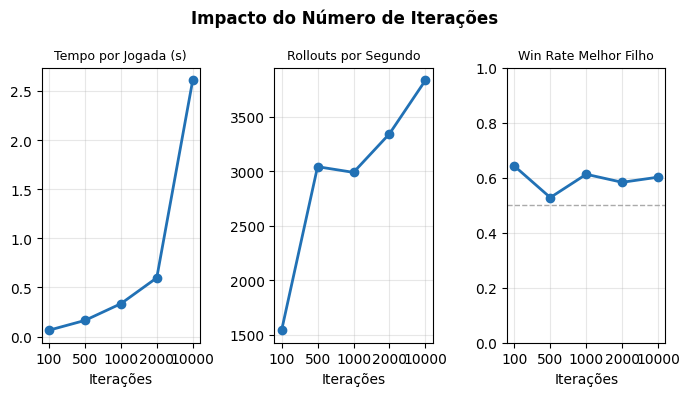

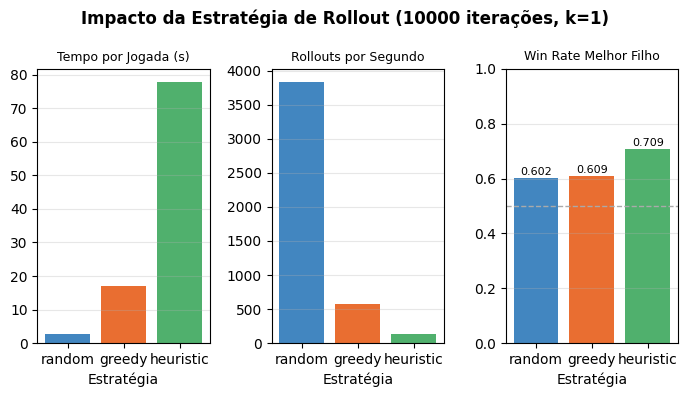

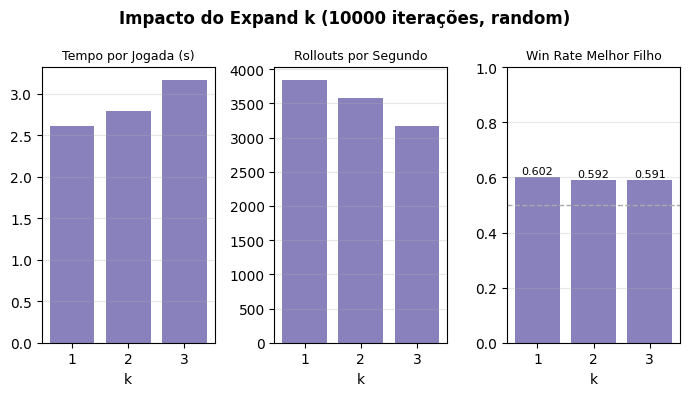

Gráficos guardados em outputs/figures/


In [ ]:
# ── Separa os resultados por tipo de análise ──────────────────────────────────
r_iter    = [r for r in results_metrics if r['rollout_strategy'] == 'random' and r['expand_k'] == 1]
r_rollout = [r for r in results_metrics if r['iterations'] == 10000 and r['expand_k'] == 1]
r_k       = [r for r in results_metrics if r['iterations'] == 10000 and r['rollout_strategy'] == 'random']

# ── Gráfico 1: Impacto das Iterações ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(7, 4))
fig.suptitle('Impacto do Número de Iterações', fontsize=12, fontweight='bold')

iter_labels = [str(r['iterations']) for r in r_iter]
ax = axes[0]
ax.plot(iter_labels, [r['elapsed'] for r in r_iter], marker='o', color='#2171b5', linewidth=2)
ax.set_title('Tempo por Jogada (s)', fontsize=9)
ax.set_xlabel('Iterações')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(iter_labels, [r['rollouts_per_sec'] for r in r_iter], marker='o', color='#2171b5', linewidth=2)
ax.set_title('Rollouts por Segundo', fontsize=9)
ax.set_xlabel('Iterações')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(iter_labels, [r['best_wr'] for r in r_iter], marker='o', color='#2171b5', linewidth=2)
ax.axhline(0.5, linestyle='--', color='#aaa', linewidth=1)
ax.set_title('Win Rate Melhor Filho', fontsize=9)
ax.set_xlabel('Iterações')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'mcts_iter.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 2: Impacto da Estratégia de Rollout ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(7, 4))
fig.suptitle('Impacto da Estratégia de Rollout (10000 iterações, k=1)', fontsize=12, fontweight='bold')

rollout_labels = [r['rollout_strategy'] for r in r_rollout]
cores_rollout  = ['#2171b5', '#e6550d', '#31a354']

ax = axes[0]
ax.bar(rollout_labels, [r['elapsed'] for r in r_rollout], color=cores_rollout, alpha=0.85)
ax.set_title('Tempo por Jogada (s)', fontsize=9)
ax.set_xlabel('Estratégia')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(rollout_labels, [r['rollouts_per_sec'] for r in r_rollout], color=cores_rollout, alpha=0.85)
ax.set_title('Rollouts por Segundo', fontsize=9)
ax.set_xlabel('Estratégia')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
bars = ax.bar(rollout_labels, [r['best_wr'] for r in r_rollout], color=cores_rollout, alpha=0.85)
ax.axhline(0.5, linestyle='--', color='#aaa', linewidth=1)
ax.set_title('Win Rate Melhor Filho', fontsize=9)
ax.set_xlabel('Estratégia')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, [r['best_wr'] for r in r_rollout]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'mcts_rollout.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 3: Impacto do Expand k ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(7, 4))
fig.suptitle('Impacto do Expand k (10000 iterações, random)', fontsize=12, fontweight='bold')

k_labels  = [str(r['expand_k']) for r in r_k]
cores_k   = ['#756bb1'] * len(r_k)

ax = axes[0]
ax.bar(k_labels, [r['elapsed'] for r in r_k], color=cores_k, alpha=0.85)
ax.set_title('Tempo por Jogada (s)', fontsize=9)
ax.set_xlabel('k')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(k_labels, [r['rollouts_per_sec'] for r in r_k], color=cores_k, alpha=0.85)
ax.set_title('Rollouts por Segundo', fontsize=9)
ax.set_xlabel('k')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
bars = ax.bar(k_labels, [r['best_wr'] for r in r_k], color=cores_k, alpha=0.85)
ax.axhline(0.5, linestyle='--', color='#aaa', linewidth=1)
ax.set_title('Win Rate Melhor Filho', fontsize=9)
ax.set_xlabel('k')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, [r['best_wr'] for r in r_k]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'mcts_k.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Gráficos guardados em outputs/figures/")

### 5.3 Distribuição de Jogadas do MCTS

Analisamos a distribuição das jogadas escolhidas pelo MCTS no dataset gerado, para perceber se o algoritmo tem preferências táticas — por exemplo, preferência por colunas centrais ou por movimentos *drop* em detrimento de *pop*.

Dataset carregado: 11200 amostras


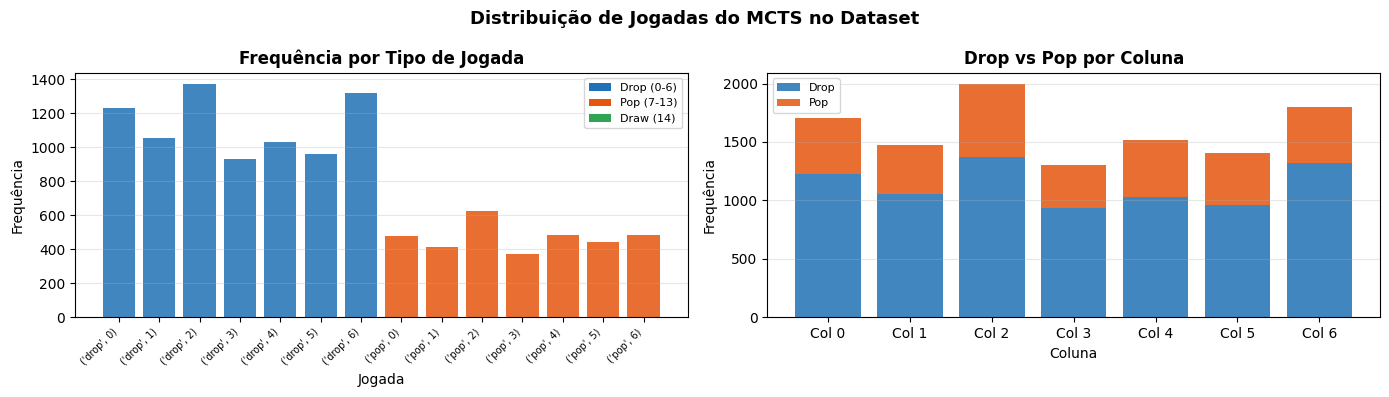


Resumo:
  Drops :   7893 (70.5%)
  Pops  :   3307  (29.5%)
  Draws :      0  (0.0%)


In [53]:
# ── Distribuição de jogadas do MCTS ──────────────────────────────────────────
import pandas as pd
from src.ml.dataset import label_to_move

# Carrega o dataset já gerado
df = pd.read_csv(os.path.join(DATA_DIR, 'popout_mcts.csv'))
print(f"Dataset carregado: {len(df)} amostras")

# Conta a frequência de cada label
label_counts = df['label'].value_counts().sort_index()

# Converte labels para descrições legíveis
label_descriptions = [str(label_to_move(l)) for l in label_counts.index]

# ── Gráfico 1: Frequência por label ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Distribuição de Jogadas do MCTS no Dataset', fontsize=13, fontweight='bold')

# cores: azul para drops (0-6), laranja para pops (7-13), verde para draw (14)
cores = []
for l in label_counts.index:
    if l <= 6:
        cores.append('#2171b5')   # drop
    elif l <= 13:
        cores.append('#e6550d')   # pop
    else:
        cores.append('#31a354')   # draw

ax = axes[0]
bars = ax.bar(range(len(label_counts)), label_counts.values, color=cores, alpha=0.85)
ax.set_title('Frequência por Tipo de Jogada', fontweight='bold')
ax.set_xlabel('Jogada')
ax.set_ylabel('Frequência')
ax.set_xticks(range(len(label_counts)))
ax.set_xticklabels(label_descriptions, rotation=45, ha='right', fontsize=7)
ax.grid(True, alpha=0.3, axis='y')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2171b5', label='Drop (0-6)'),
    Patch(facecolor='#e6550d', label='Pop (7-13)'),
    Patch(facecolor='#31a354', label='Draw (14)'),
]
ax.legend(handles=legend_elements, fontsize=8)

# ── Gráfico 2: Drop vs Pop por coluna ────────────────────────────────────────
ax = axes[1]

drop_counts = [label_counts.get(c, 0) for c in range(7)]    # drops por coluna
pop_counts  = [label_counts.get(c+7, 0) for c in range(7)]  # pops por coluna
x = range(7)

ax.bar(x, drop_counts, label='Drop', color='#2171b5', alpha=0.85)
ax.bar(x, pop_counts, bottom=drop_counts, label='Pop', color='#e6550d', alpha=0.85)
ax.set_title('Drop vs Pop por Coluna', fontweight='bold')
ax.set_xlabel('Coluna')
ax.set_ylabel('Frequência')
ax.set_xticks(x)
ax.set_xticklabels([f'Col {i}' for i in range(7)])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'mcts_jogadas.png'), dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas resumo
total = len(df)
n_drops = sum(label_counts.get(c, 0) for c in range(7))
n_pops  = sum(label_counts.get(c+7, 0) for c in range(7))
n_draws = label_counts.get(14, 0)

print(f"\nResumo:")
print(f"  Drops : {n_drops:6d} ({n_drops/total*100:.1f}%)")
print(f"  Pops  : {n_pops:6d}  ({n_pops/total*100:.1f}%)")
print(f"  Draws : {n_draws:6d}  ({n_draws/total*100:.1f}%)")

### 5.4 Discussão dos Resultados

#### Impacto do Número de Iterações
Com poucas iterações (100), o MCTS demora apenas 0.065s por jogada mas executa apenas 1542 rollouts/s. À medida que as iterações aumentam, o número de rollouts por segundo também aumenta — isto deve-se ao facto de a árvore estar mais construída e a fase de *selection* ser mais eficiente. A qualidade da decisão (win rate do melhor filho) mantém-se relativamente estável, o que sugere que **mesmo 100 iterações são suficientes para tomar boas decisões** neste estado de jogo.

#### Impacto da Estratégia de Rollout
Este é o resultado mais interessante da análise. Existe um claro **trade-off entre velocidade e qualidade**:
- `random` executa 3835 rollouts/s mas tem win rate de 0.602
- `greedy` é 6x mais lento (582 rollouts/s) com win rate de 0.609
- `heuristic` é 30x mais lento (129 rollouts/s) mas atinge o win rate mais alto: **0.709**

O `heuristic` produz simulações de maior qualidade porque antecipa dois níveis de jogadas, mas o custo computacional é muito elevado. Para o PopOut, onde o espaço de estados é grande, o `heuristic` é a melhor escolha quando há tempo disponível.

#### Impacto do Expand k
O MCTS standard (k=1) obteve o melhor win rate (0.602) contra k=2 (0.592) e k=3 (0.591). Com o mesmo orçamento de iterações, **expandir mais filhos por iteração prejudica a profundidade da árvore**, resultando em decisões de menor qualidade. k=1 é a melhor escolha para o PopOut.

#### Distribuição de Jogadas
O MCTS escolhe **70.5% drops e 29.5% pops**, nunca declarando empate. A distribuição por coluna é relativamente uniforme, sem a forte preferência pelo centro que se observa no Connect-4 — o movimento pop introduz dinâmicas táticas que tornam todas as colunas relevantes.

O dataset foi gerado em **duas fases** de self-play MCTS, acumulando um total de **26.054 amostras**:

**Fase 1 — Dataset base** (gerado com `dataset.py`):

| Estratégia | Iterações/jogada | Jogos | Amostras aprox. |
|------------|-----------------|-------|-----------------|
| `random` | 300 | ~200 | ~11.000 |

**Fase 2 — Dataset expandido** (gerado com `generate_extra_data.py`, adicionado ao CSV existente):

| Estratégia | Tempo/jogada | Jogos | Descrição |
|------------|-------------|-------|-----------|
| `heuristic` | 5s (early) / 2.5s (late) | 300 | Maior qualidade — 2-ply look-ahead |
| `greedy` | 5s (early) / 2.5s (late) | 150 | Equilíbrio velocidade/qualidade |
| `random` | 5s (early) / 2.5s (late) | 50 | Diversidade e exploração |

O dataset final encontra-se em `data/popout_mcts.csv` com **26.054 amostras**.
### Codificação das features e labels

**Feature vector (43 inteiros):**
- Features `r0c0` a `r5c6`: células do tabuleiro em ordem linha-a-linha (0=vazio, 1=P1, 2=P2)
- Feature `current_player`: jogador atual (1 ou 2)

**Labels (inteiros 0–14):**

| Label | Movimento |
|-------|-----------|
| 0–6 | `drop` na coluna 0–6 |
| 7–13 | `pop` na coluna 0–6 |
| 14 | `draw` |

In [2]:
# ── Carrega e explora o dataset ───────────────────────────────────────────────
from src.ml.dataset import load_dataset, label_to_move, FEATURE_NAMES

# Carrega o dataset gerado
X_pop, y_pop = load_dataset()

print(f"Total de amostras : {len(X_pop)}")
print(f"Features por amostra: {len(X_pop[0])}")
print(f"Labels únicos     : {sorted(set(y_pop))}")
print(f"\nExemplo de feature vector (primeira amostra):")
print(f"  {X_pop[0]}")
print(f"  Label: {y_pop[0]} → {label_to_move(y_pop[0])}")

Loaded 26054 samples <- C:\Users\fcpor\OneDrive\Documentos\GitHub\IAPopOut\data\popout_mcts.csv
Total de amostras : 26054
Features por amostra: 43
Labels únicos     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Exemplo de feature vector (primeira amostra):
  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
  Label: 5 → ('drop', 5)


In [5]:
# ── Composição e validação do dataset ────────────────────────────────────────
import os
import pandas as pd
from collections import Counter

DATA_DIR = 'data'  # ajusta se o teu notebook usar outro caminho

df = pd.read_csv(os.path.join(DATA_DIR, 'popout_mcts.csv'))

print("=" * 50)
print(f"  VALIDAÇÃO DO DATASET FINAL")
print("=" * 50)
print(f"  Ficheiro        : data/popout_mcts.csv")
print(f"  Total amostras  : {len(df):,}")
print(f"  Features (cols) : {len(df.columns) - 1}  (+1 label)")
print(f"  Labels únicos   : {sorted(df['label'].unique())}")
print()

# Distribuição por tipo de movimento
label_counts = df['label'].value_counts().sort_index()
n_drops = sum(label_counts.get(c, 0) for c in range(7))
n_pops  = sum(label_counts.get(c+7, 0) for c in range(7))
n_draws = label_counts.get(14, 0)
total   = len(df)

print(f"  Distribuição por tipo de movimento:")
print(f"    Drop  (labels 0–6)  : {n_drops:6,}  ({n_drops/total*100:.1f}%)")
print(f"    Pop   (labels 7–13) : {n_pops:6,}  ({n_pops/total*100:.1f}%)")
print(f"    Draw  (label 14)    : {n_draws:6,}  ({n_draws/total*100:.1f}%)")
print()

# Verificação de valores nulos / inválidos
assert df.isnull().sum().sum() == 0, "Existem valores nulos!"
assert df['label'].between(0, 14).all(), "Labels fora do intervalo 0–14!"
assert df['current_player'].isin([1, 2]).all(), "current_player inválido!"
print("  Validação: sem valores nulos, labels e jogadores válidos. ✓")

  VALIDAÇÃO DO DATASET FINAL
  Ficheiro        : data/popout_mcts.csv
  Total amostras  : 26,054
  Features (cols) : 43  (+1 label)
  Labels únicos   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]

  Distribuição por tipo de movimento:
    Drop  (labels 0–6)  : 21,612  (83.0%)
    Pop   (labels 7–13) :  4,442  (17.0%)
    Draw  (label 14)    :      0  (0.0%)

  Validação: sem valores nulos, labels e jogadores válidos. ✓


In [4]:
import os

# Verifica o ficheiro que está a ser lido
path = os.path.join('data', 'popout_mcts.csv')
with open(path) as f:
    n_lines = sum(1 for _ in f) - 1  # -1 para o header
print(f"Ficheiro: {path}")
print(f"Amostras: {n_lines}")
print(f"Path absoluto: {os.path.abspath(path)}")

Ficheiro: data\popout_mcts.csv
Amostras: 26054
Path absoluto: c:\Users\fcpor\OneDrive\Documentos\GitHub\IAPopOut\data\popout_mcts.csv


### Como foi gerado o dataset

A geração do dataset seguiu uma abordagem **iterativa** para maximizar qualidade e diversidade:

1. **Fase 1** — Geração base com `src/ml/dataset.py`: joga ~200 partidas com MCTS de 300 iterações/jogada (estratégia `random`), produzindo ~11.000 amostras iniciais.

2. **Fase 2** — Expansão com `generate_extra_data.py`: adiciona 500 jogos novos usando tempo-limite por jogada (5s nas primeiras 10 jogadas, 2.5s a partir daí), com estratégias heurísticas mais fortes. O script usa checkpoints parciais a cada 10 jogos (guardados em `mcts_dataset_parcial.csv`) e faz *append* ao CSV principal para não perder progresso. O dataset anterior é **preservado** conforme solicitado.

Esta estratégia de geração em duas fases garante:
- **Diversidade**: amostras de diferentes fases do jogo (abertura, meio-jogo, final)
- **Qualidade crescente**: as fases 2 usam heurísticas mais fortes, produzindo labels mais precisos
- **Robustez**: o checkpoint parcial evita perda de dados em caso de interrupção (a geração da fase 2 demora ~18–20 horas)

In [ ]:
Lógica central do script:
#
# for move_count, board in game:
#     # Tempo maior nas primeiras 10 jogadas (fase de abertura)
#     max_time = 5.0 if move_count < 10 else 2.5
#
#     agent = make_mcts_agent(
#         iterations           = 10_000,
#         rollout_strategy     = strategy,   # 'heuristic' / 'greedy' / 'random'
#         max_time             = max_time,
#         early_stop_threshold = 0.95,       # para cedo se win-rate > 95%
#     )
#     move = agent(board)
#     dataset.append((board_to_features(board), move_to_label(move)))
#
#     # Checkpoint parcial a cada 10 jogos (evita perda em caso de crash)
#     if (game_idx + 1) % 10 == 0:
#         save_partial(dataset)
#